# Análise das Exportações de Pescados no RS (2015–2025)

Este notebook segue o mesmo padrão das análises anteriores: consolidação dos dados por URF, evolução anual do peso exportado, análise dos 3 maiores portos/URFs e participação percentual por URF no total exportado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

arquivo = "data_RS_Pescados.xlsx"
produto_titulo = "Pescados"
produto_titulo_minusculo = "pescados"
saida_imagem = "participacao_percentual_urf_pescados.png"

# Mapeamento padronizado das URFs usadas nas análises
nomes_portos = {
    "1010252": "1010252 - JAGUARAO",
    "1010253": "1010253 - BAGE",
    "1010351": "1010351 - IRF SANTANA DO LIVRAMENTO",
    "1010900": "1010900 - URUGUAIANA",
    "1010953": "1010953 - SAO BORJA",
    "1015500": "1015500 - CHUI",
    "1015600": "1015600 - SANTANA DO LIVRAMENTO",
    "1017500": "1017500 - ALF - URUGUAIANA",
    "1017503": "1017503 - IRF - SÃO BORJA",
    "1017600": "1017600 - AEROPORTO SALGADO FILHO - PORTO ALEGRE",
    "1017700": "1017700 - PORTO DE RIO GRANDE",
    "1017701": "1017701 - IRF - CHUÍ",
    "1017800": "1017800 - ALF - PORTO ALEGRE",
    "1017801": "1017801 - IRF - AEROPORTO INTERNACIONAL SALGADO FILHO",
    "1017900": "1017900 - ALF - SANTANA DO LIVRAMENTO",
}

ordem_urfs = [
    "1010252", "1010253", "1010351", "1010900", "1010953",
    "1015500", "1015600", "1017500", "1017503", "1017600",
    "1017700", "1017701", "1017800", "1017801", "1017900"
]

# Leitura de todas as abas
abas = pd.read_excel(arquivo, sheet_name=None)

lista_dfs = []
for nome_aba, df in abas.items():
    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df = df.copy()
        df["Codigo_URF"] = codigo
        df["Porto_URF"] = nomes_portos.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs.append(df)

base = pd.concat(lista_dfs, ignore_index=True)

# Tratamento de números: valores ausentes ou '-' viram zero
base["Peso_KG"] = pd.to_numeric(base["Peso_KG"], errors="coerce").fillna(0)
base["Valor_USD"] = pd.to_numeric(base["Valor_USD"], errors="coerce").fillna(0)
base["Ano"] = pd.to_numeric(base["Ano"], errors="coerce").astype("Int64")

base.head()

,Agrupamento,Transacao,Ano,Produto,Regiao_UF_URF,Valor_USD,Peso_KG,Tipo_Local,Local,Codigo_URF,Porto_URF
0,Acordo Agrícola OMC e Pescados,Exportacao,2015,(1º Nível) PESCADOS,(URF) 1010252 - JAGUARAO,1514466.0,306453.0,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
1,Acordo Agrícola OMC e Pescados,Exportacao,2016,(1º Nível) PESCADOS,(URF) 1010252 - JAGUARAO,143811.0,36020.0,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
2,Acordo Agrícola OMC e Pescados,Exportacao,2017,(1º Nível) PESCADOS,(URF) 1010252 - JAGUARAO,382549.0,84067.0,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
3,Acordo Agrícola OMC e Pescados,Exportacao,2018,(1º Nível) PESCADOS,(URF) 1010252 - JAGUARAO,1305633.0,264541.0,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO
4,Acordo Agrícola OMC e Pescados,Exportacao,2019,(1º Nível) PESCADOS,(URF) 1010252 - JAGUARAO,1245099.0,267703.0,URF,1010252 - JAGUARAO,1010252,1010252 - JAGUARAO


## Consolidação por ano e por Porto/URF

In [2]:
df_porto_ano = (
    base
    .groupby(["Ano", "Porto_URF"], as_index=False)
    .agg(Peso_KG=("Peso_KG", "sum"), Valor_USD=("Valor_USD", "sum"))
)

df_porto_ano["Peso_milhoes"] = df_porto_ano["Peso_KG"] / 1_000_000

total_exportado_kg = base["Peso_KG"].sum()
total_exportado_milhoes = total_exportado_kg / 1_000_000

resumo_urf = (
    base
    .groupby("Porto_URF", as_index=False)
    .agg(Peso_KG=("Peso_KG", "sum"), Valor_USD=("Valor_USD", "sum"))
)
resumo_urf["Participacao_%"] = resumo_urf["Peso_KG"] / total_exportado_kg * 100
resumo_urf = resumo_urf.sort_values("Peso_KG", ascending=False)

print(f"Total exportado de {produto_titulo_minusculo}: {total_exportado_milhoes:,.2f} milhões de KG")
resumo_urf

Total exportado de pescados: 258.12 milhões de KG


,Porto_URF,Peso_KG,Valor_USD,Participacao_%
6,1017700 - PORTO DE RIO GRANDE,185131164.0,382287450.0,71.722572
4,1017500 - ALF - URUGUAIANA,32240028.0,123707542.0,12.490267
7,1017701 - IRF - CHUÍ,17794884.0,21186418.0,6.894003
2,1010900 - URUGUAIANA,13970322.0,49632564.0,5.412311
0,1010252 - JAGUARAO,4895184.0,22140376.0,1.896467
1,1010351 - IRF SANTANA DO LIVRAMENTO,1698734.0,7382554.0,0.658115
5,1017503 - IRF - SÃO BORJA,1673244.0,11901260.0,0.648240
3,1015500 - CHUI,650088.0,2905578.0,0.251854
8,1017800 - ALF - PORTO ALEGRE,50432.0,354598.0,0.019538
9,1017801 - IRF - AEROPORTO INTERNACIONAL SALGAD...,17122.0,228932.0,0.006633


## Gráfico 1 — Evolução do peso exportado por Porto/URF

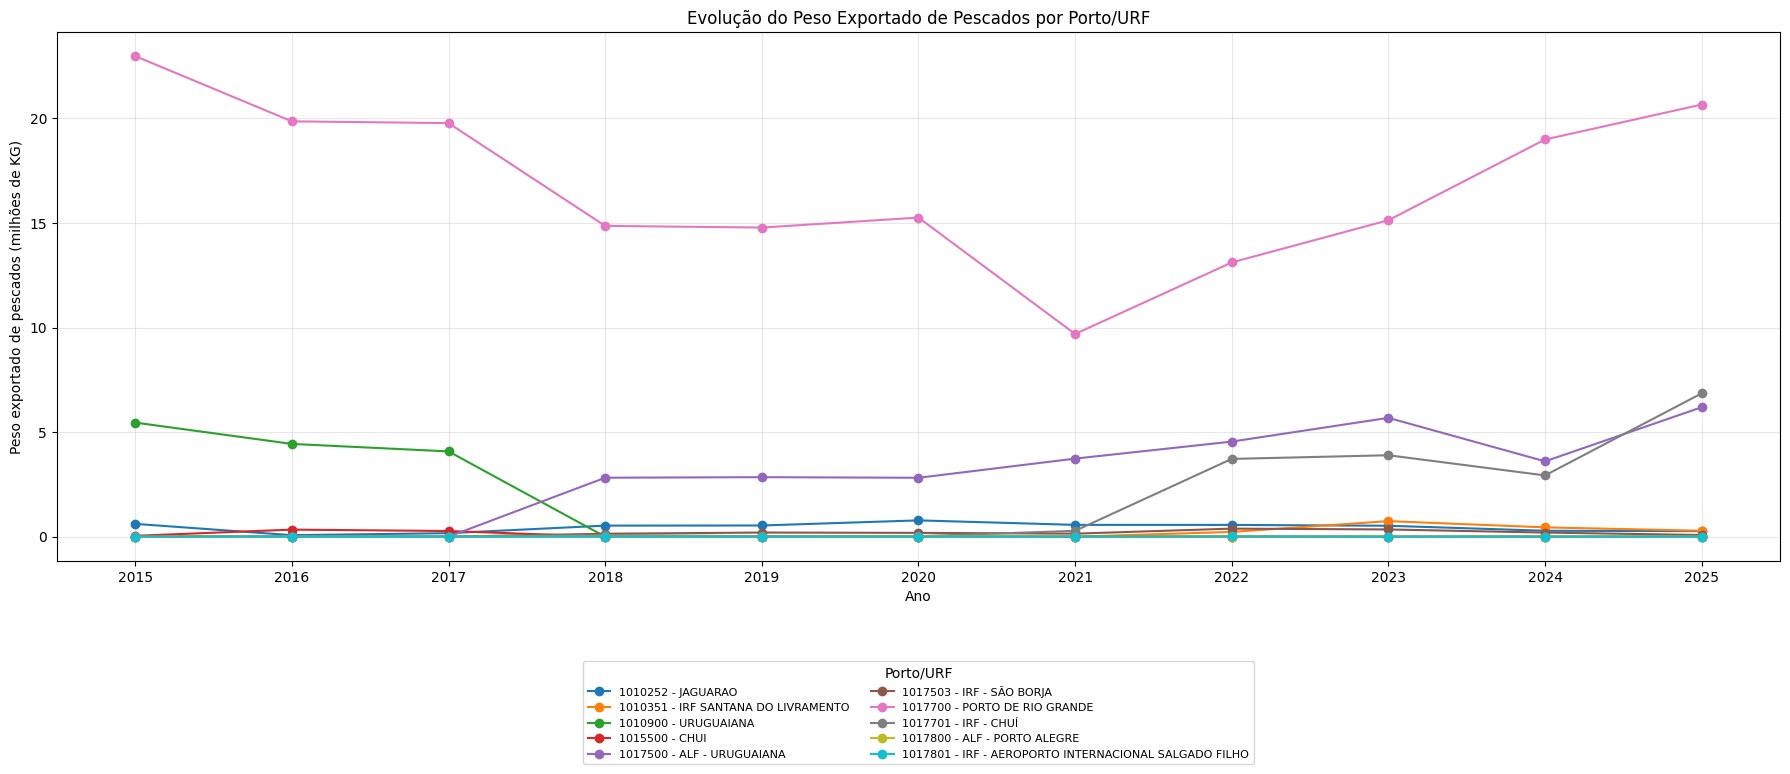

In [3]:
grafico = df_porto_ano.copy()

tabela_grafico = grafico.pivot(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes"
).fillna(0)

plt.figure(figsize=(18, 8))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        label=porto
    )

plt.title(f"Evolução do Peso Exportado de {produto_titulo} por Porto/URF")
plt.xlabel("Ano")
plt.ylabel(f"Peso exportado de {produto_titulo_minusculo} (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 2 — Evolução dos 3 maiores Portos/URFs

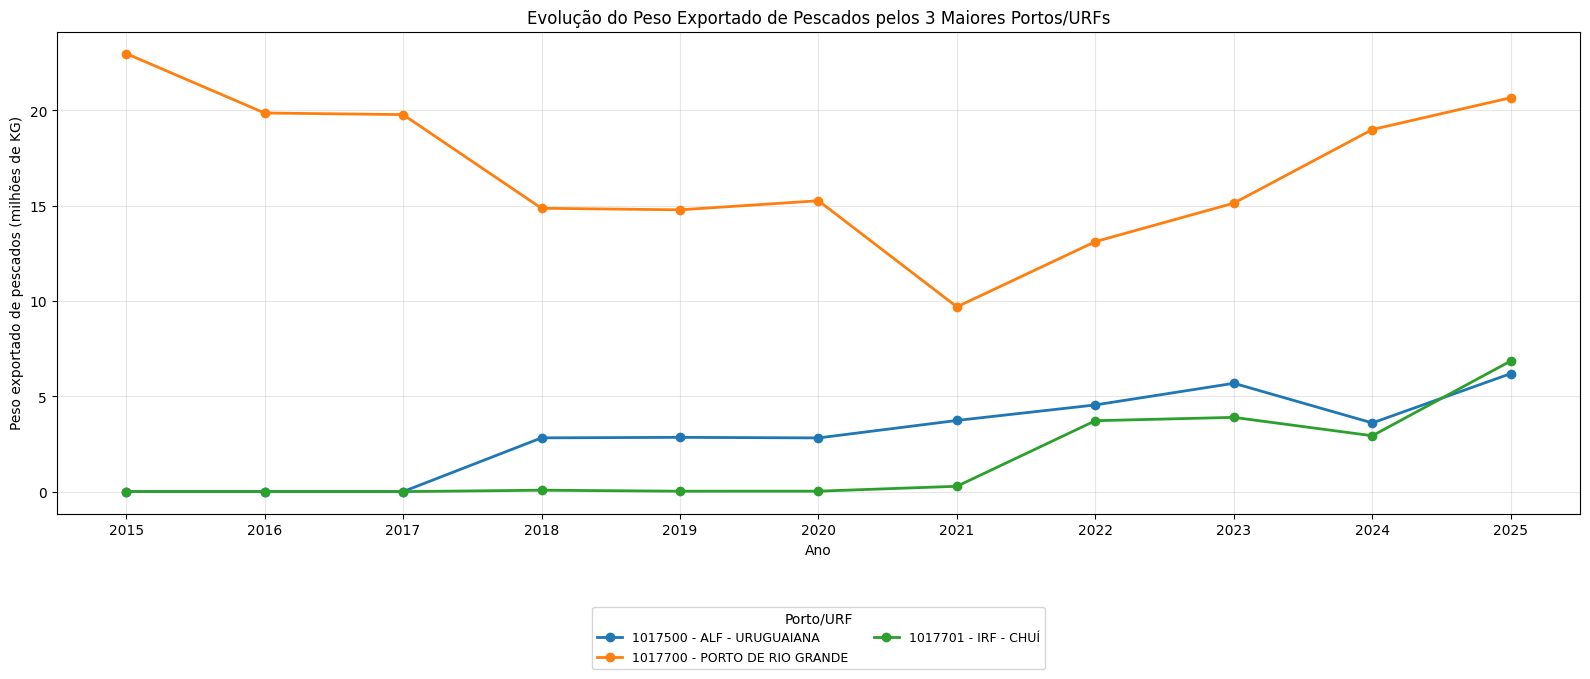

In [4]:
grafico = df_porto_ano.copy()

# Identificar os 3 maiores exportadores no total do período
top3_portos = (
    grafico
    .groupby("Porto_URF")["Peso_milhoes"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# Filtrar apenas o Top 3
grafico_top3 = grafico[grafico["Porto_URF"].isin(top3_portos)]

# Criar tabela para o gráfico
tabela_grafico = grafico_top3.pivot_table(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 7))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        linewidth=2,
        label=porto
    )

plt.title(f"Evolução do Peso Exportado de {produto_titulo} pelos 3 Maiores Portos/URFs")
plt.xlabel("Ano")
plt.ylabel(f"Peso exportado de {produto_titulo_minusculo} (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=9
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 3 — Participação percentual por URF no total exportado

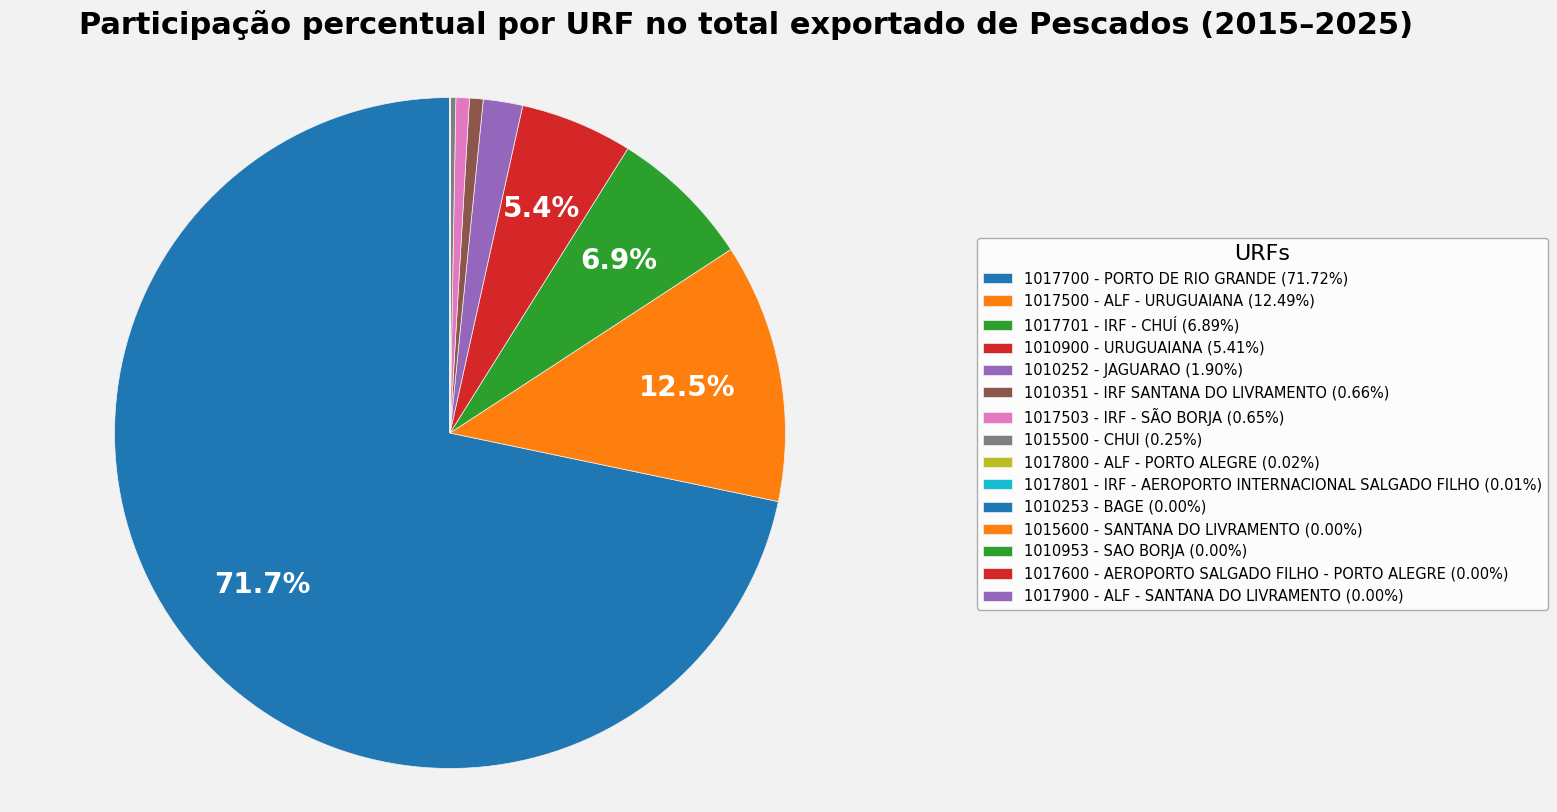

Imagem salva em: participacao_percentual_urf_pescados.png


In [5]:
# Tabela de participação, mantendo a lista padronizada de URFs mesmo quando alguma não aparece no arquivo
participacao = (
    base
    .groupby("Codigo_URF", as_index=False)
    .agg(Peso_KG=("Peso_KG", "sum"))
)

participacao_completa = pd.DataFrame({"Codigo_URF": ordem_urfs})
participacao_completa = participacao_completa.merge(participacao, on="Codigo_URF", how="left").fillna({"Peso_KG": 0})
participacao_completa["Porto_URF"] = participacao_completa["Codigo_URF"].map(nomes_portos)
participacao_completa["Participacao_%"] = participacao_completa["Peso_KG"] / total_exportado_kg * 100
participacao_completa = participacao_completa.sort_values("Participacao_%", ascending=False).reset_index(drop=True)

# Para desenhar categorias com 0, adiciona-se um valor visual mínimo, sem alterar os percentuais exibidos na legenda
valores_plot = participacao_completa["Peso_KG"].where(participacao_completa["Peso_KG"] > 0, 1e-9)
percentuais = participacao_completa["Participacao_%"]
rotulos_legenda = [
    f"{nome} ({pct:.2f}%)"
    for nome, pct in zip(participacao_completa["Porto_URF"], percentuais)
]

def autopct_func(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

fig = plt.figure(figsize=(16, 9), facecolor="#f2f2f2")
ax = fig.add_axes([0.04, 0.08, 0.55, 0.82], facecolor="#f2f2f2")

wedges, texts, autotexts = ax.pie(
    valores_plot,
    startangle=90,
    autopct=autopct_func,
    pctdistance=0.72,
    textprops={"color": "white", "fontsize": 16, "weight": "bold"},
    wedgeprops={"linewidth": 0.5, "edgecolor": "#f2f2f2"}
)

for texto in autotexts:
    texto.set_fontsize(20)
    texto.set_weight("bold")

ax.axis("equal")
fig.suptitle(
    f"Participação percentual por URF no total exportado de {produto_titulo} (2015–2025)",
    fontsize=22,
    fontweight="bold",
    y=0.96
)

leg = fig.legend(
    wedges,
    rotulos_legenda,
    title="URFs",
    loc="center left",
    bbox_to_anchor=(0.64, 0.50),
    frameon=True,
    fontsize=10.5,
    title_fontsize=16
)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("#999999")

plt.savefig(saida_imagem, dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

print(f"Imagem salva em: {saida_imagem}")

## Leitura rápida dos resultados

A célula abaixo resume a concentração da exportação por URF no período completo.

In [6]:
top3_resumo = resumo_urf.head(3).copy()
participacao_top3 = top3_resumo["Participacao_%"].sum()

print("Top 3 URFs no total exportado:")
for _, linha in top3_resumo.iterrows():
    print(f"- {linha['Porto_URF']}: {linha['Peso_KG'] / 1_000_000:.2f} milhões de KG ({linha['Participacao_%']:.2f}%)")

print(f"
Participação somada do Top 3: {participacao_top3:.2f}%")

SyntaxError: unterminated f-string literal (detected at line 8) (1393093546.py, line 8)